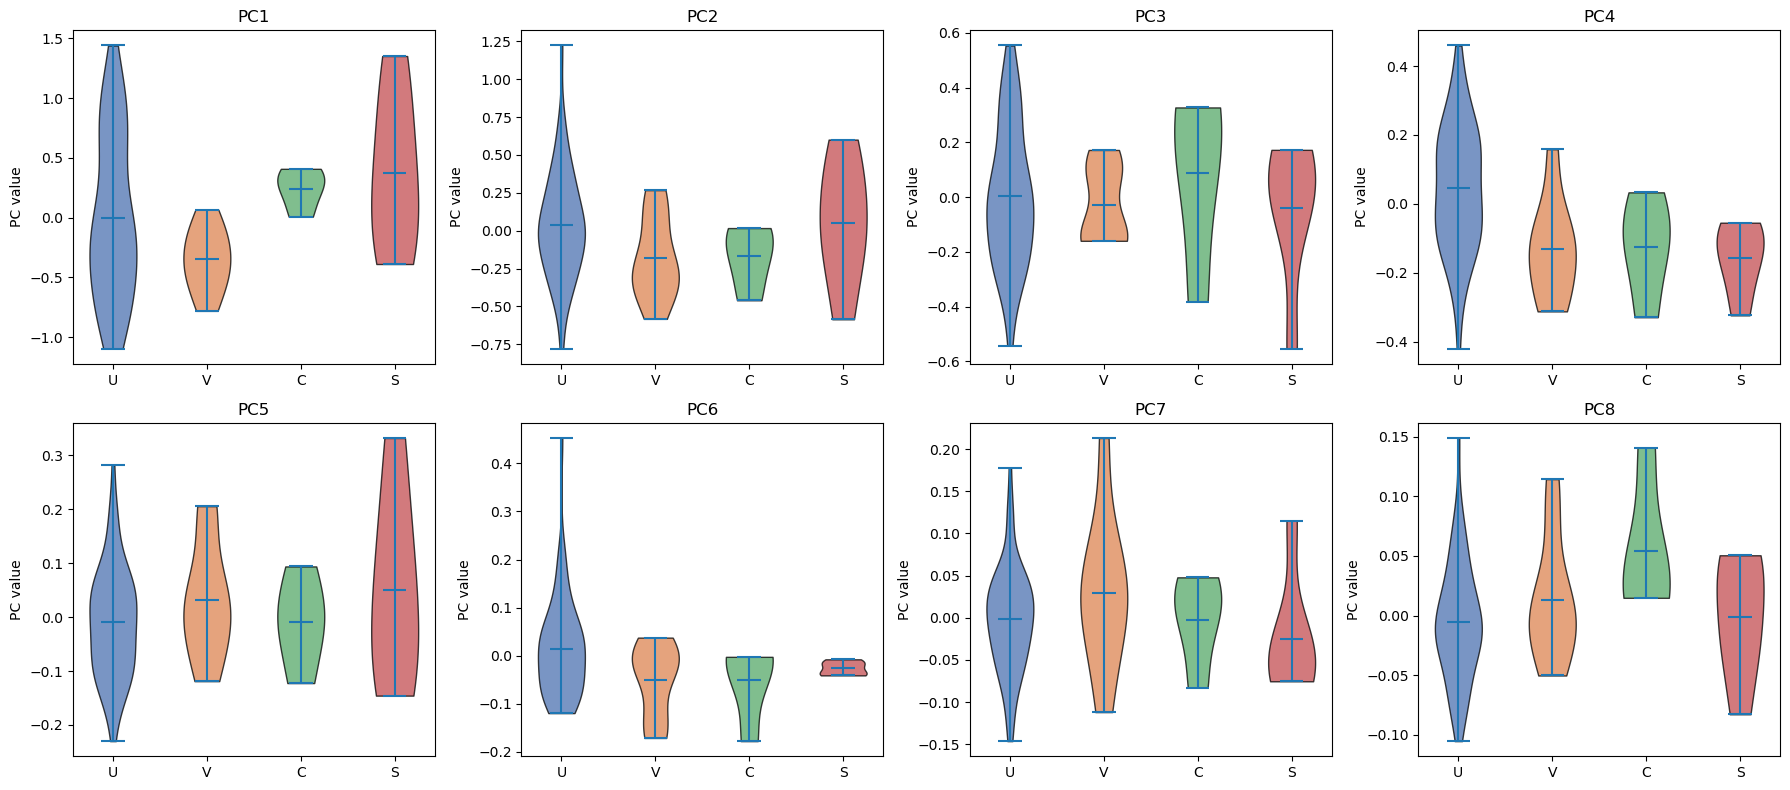

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# =========================
# 1. File paths（你的本地路径）
# =========================
json_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/5_PCA/"
    "siphon_aligned_with_PCs.json"
)

csv_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/3_Classification/"
    "classified_centerlines_BestDrop.csv"
)

# =========================
# 2. Load data
# =========================
df_cls = pd.read_csv(csv_path)

with open(json_path, "r") as f:
    pcs_data = json.load(f)

rows = []
for fname, content in pcs_data.items():
    row = {"Filename": fname.replace(".vtk", "")}
    for k, v in content["pcs"].items():
        row[k] = v
    rows.append(row)

df_pcs = pd.DataFrame(rows)

# Merge classification + PCA
df = pd.merge(df_cls, df_pcs, on="Filename", how="inner")

pcs = [f"PC{i}" for i in range(1, 9)]
types = ["U", "V", "C", "S"]

# =========================
# 3. Color map for UVCS
# =========================
color_map = {
    "U": "#4C72B0",  # blue
    "V": "#DD8452",  # orange
    "C": "#55A868",  # green
    "S": "#C44E52"   # red
}

# =========================
# 4. 2 x 4 violin plot
# =========================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, pc in zip(axes, pcs):
    data = [df[df["Type"] == t][pc].dropna() for t in types]

    parts = ax.violinplot(
        data,
        showmeans=True,
        showextrema=True
    )

    # Color each violin by UVCS
    for body, t in zip(parts["bodies"], types):
        body.set_facecolor(color_map[t])
        body.set_edgecolor("black")
        body.set_alpha(0.75)

    ax.set_xticks(range(1, len(types) + 1))
    ax.set_xticklabels(types)
    ax.set_title(pc)
    ax.set_ylabel("PC value")

plt.tight_layout()
plt.show()


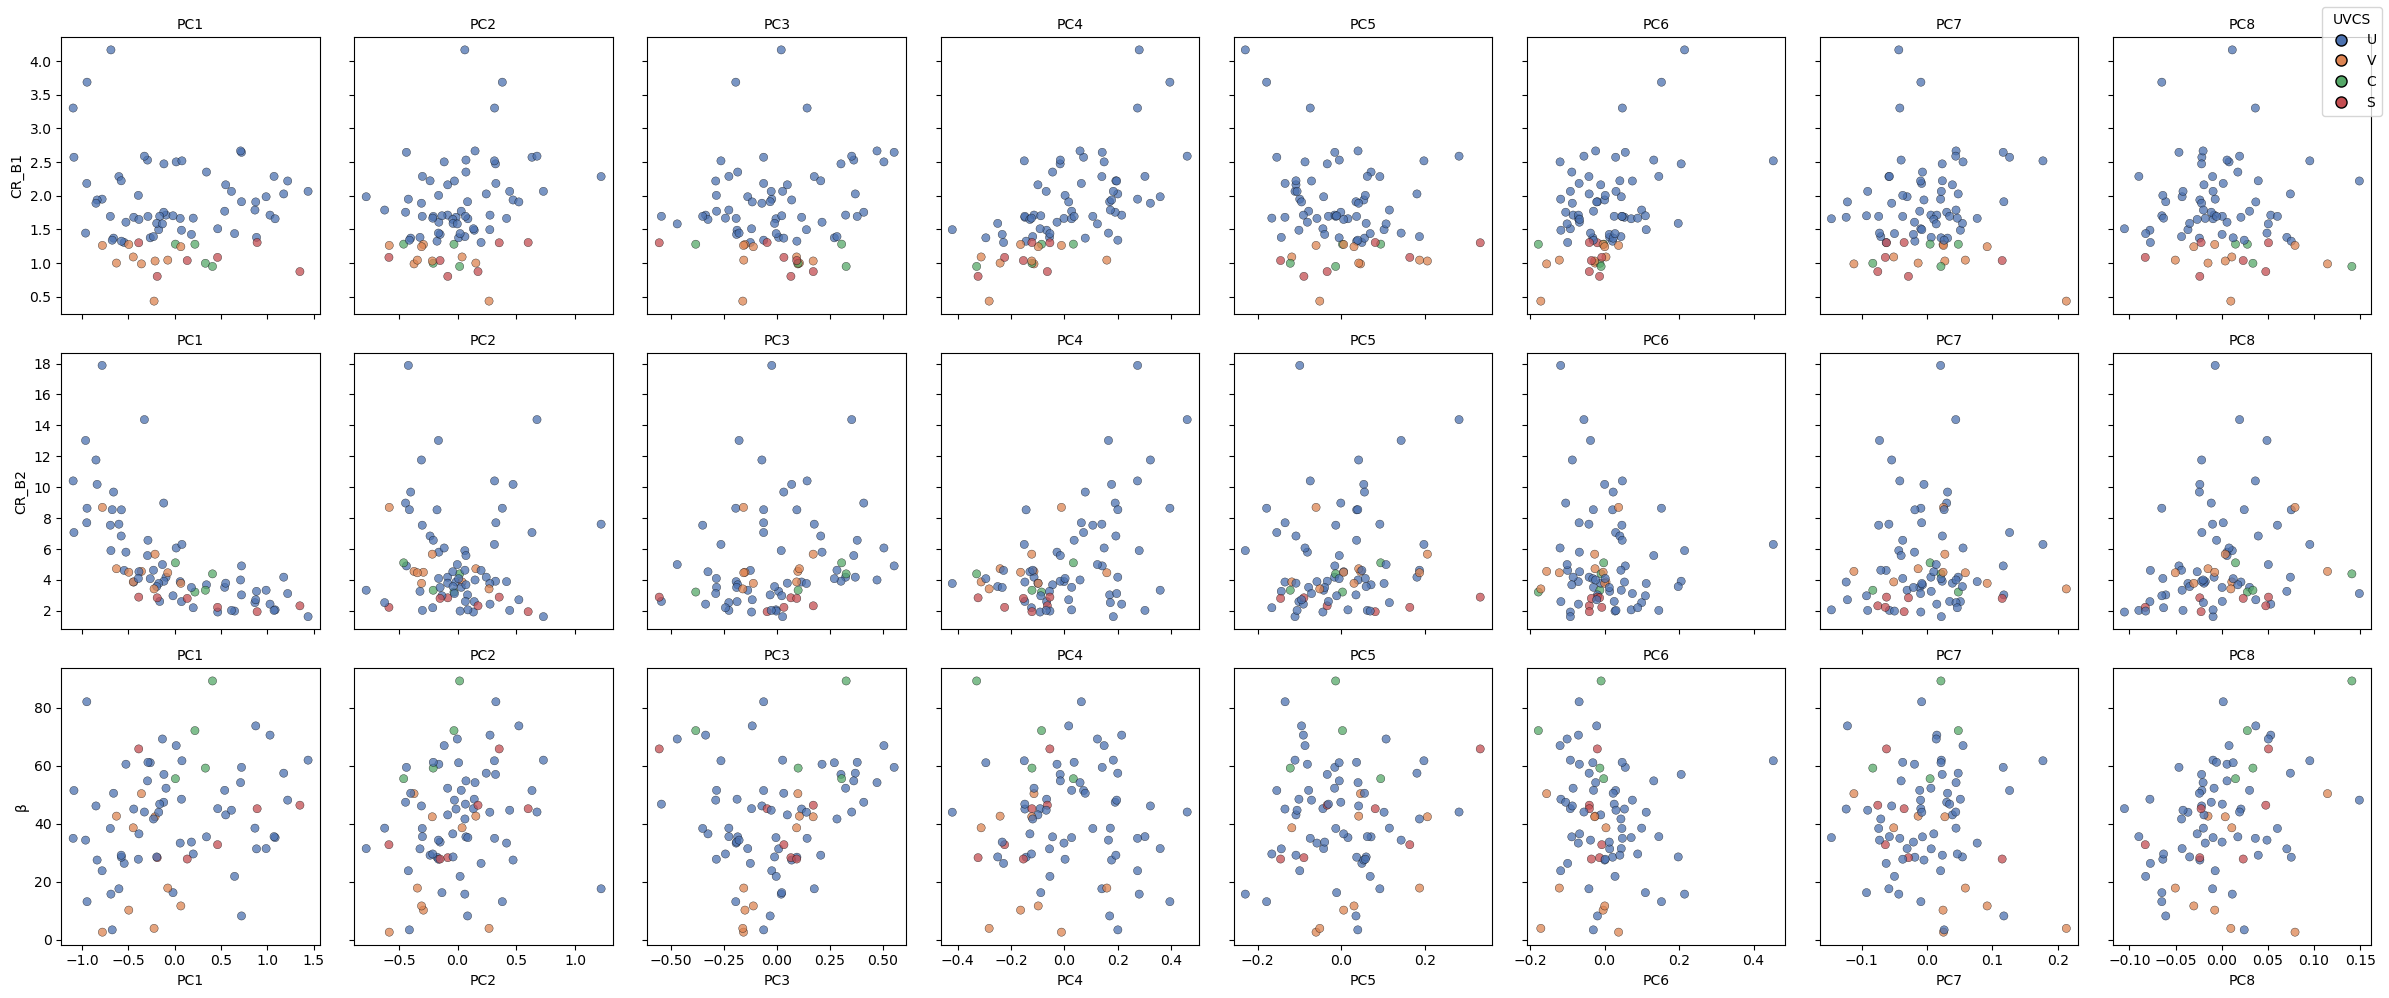

In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# =========================
# 1. File paths
# =========================
json_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/5_PCA/"
    "siphon_aligned_with_PCs.json"
)

csv_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/3_Classification/"
    "classified_centerlines_BestDrop.csv"
)

# =========================
# 2. Load CSV (shape parameters + UVCS)
# =========================
df_cls = pd.read_csv(csv_path)

# =========================
# 3. Load PCA JSON -> DataFrame
# =========================
with open(json_path, "r") as f:
    pcs_data = json.load(f)

rows = []
for fname, content in pcs_data.items():
    row = {"Filename": fname.replace(".vtk", "")}
    for k, v in content["pcs"].items():
        row[k] = v
    rows.append(row)

df_pcs = pd.DataFrame(rows)

# =========================
# 4. Merge
# =========================
df = pd.merge(df_cls, df_pcs, on="Filename", how="inner")

# （可选）检查是否有合并失败的案例
# print("CSV rows:", len(df_cls), "JSON rows:", len(df_pcs), "Merged rows:", len(df))

# =========================
# 5. Scatter plots: Shape params vs PC1–PC8
# =========================
shape_params = ["CR_B1", "CR_B2", "β"]
pcs_main = [f"PC{i}" for i in range(1, 9)]  # PC1 ~ PC8

color_map = {
    "U": "#4C72B0",
    "V": "#DD8452",
    "C": "#55A868",
    "S": "#C44E52"
}

# 3 rows x 8 cols
fig, axes = plt.subplots(
    nrows=len(shape_params),
    ncols=len(pcs_main),
    figsize=(24, 10),     # 列数多，建议加宽
    sharex="col",
    sharey="row"
)

# 如果只有一行/一列时，axes 可能不是二维；这里强制二维处理更稳
if len(shape_params) == 1:
    axes = [axes]
if len(pcs_main) == 1:
    axes = [[ax] for ax in axes]

for i, sp in enumerate(shape_params):
    for j, pc in enumerate(pcs_main):
        ax = axes[i][j]

        ax.scatter(
            df[pc],
            df[sp],
            c=df["Type"].map(color_map),
            s=35,
            alpha=0.75,
            edgecolor="k",
            linewidth=0.3
        )

        # 轴标签：只在最下行显示 x label，只在最左列显示 y label
        if i == len(shape_params) - 1:
            ax.set_xlabel(pc)
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel(sp)
        else:
            ax.set_ylabel("")

        ax.set_title(pc, fontsize=10)

# （可选）添加图例：用虚拟点构造 legend
handles = []
labels = []
for t, col in color_map.items():
    h = plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=col, markeredgecolor='k',
                   markersize=8, linewidth=0)
    handles.append(h)
    labels.append(t)

fig.legend(handles, labels, title="UVCS", loc="upper right")

plt.tight_layout()
plt.show()


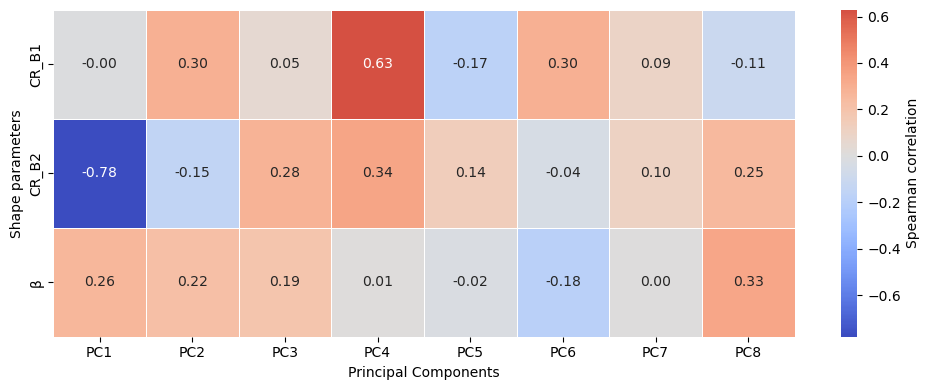

In [4]:
# =========================
# 6. Correlation heatmap (Spearman)
# =========================
shape_params = ["CR_B1", "CR_B2", "β"]
pcs_all = [f"PC{i}" for i in range(1, 9)]

corr = pd.DataFrame(
    index=shape_params,
    columns=pcs_all,
    dtype=float
)

for sp in shape_params:
    for pc in pcs_all:
        corr.loc[sp, pc] = df[sp].corr(df[pc], method="spearman")

plt.figure(figsize=(10, 4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"}
)

plt.xlabel("Principal Components")
plt.ylabel("Shape parameters")
plt.tight_layout()
plt.show()


/var/folders/2q/pmfj5lyn2b59kx0_bw6hgmv00000gn/T/ipykernel_36336/2510896841.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


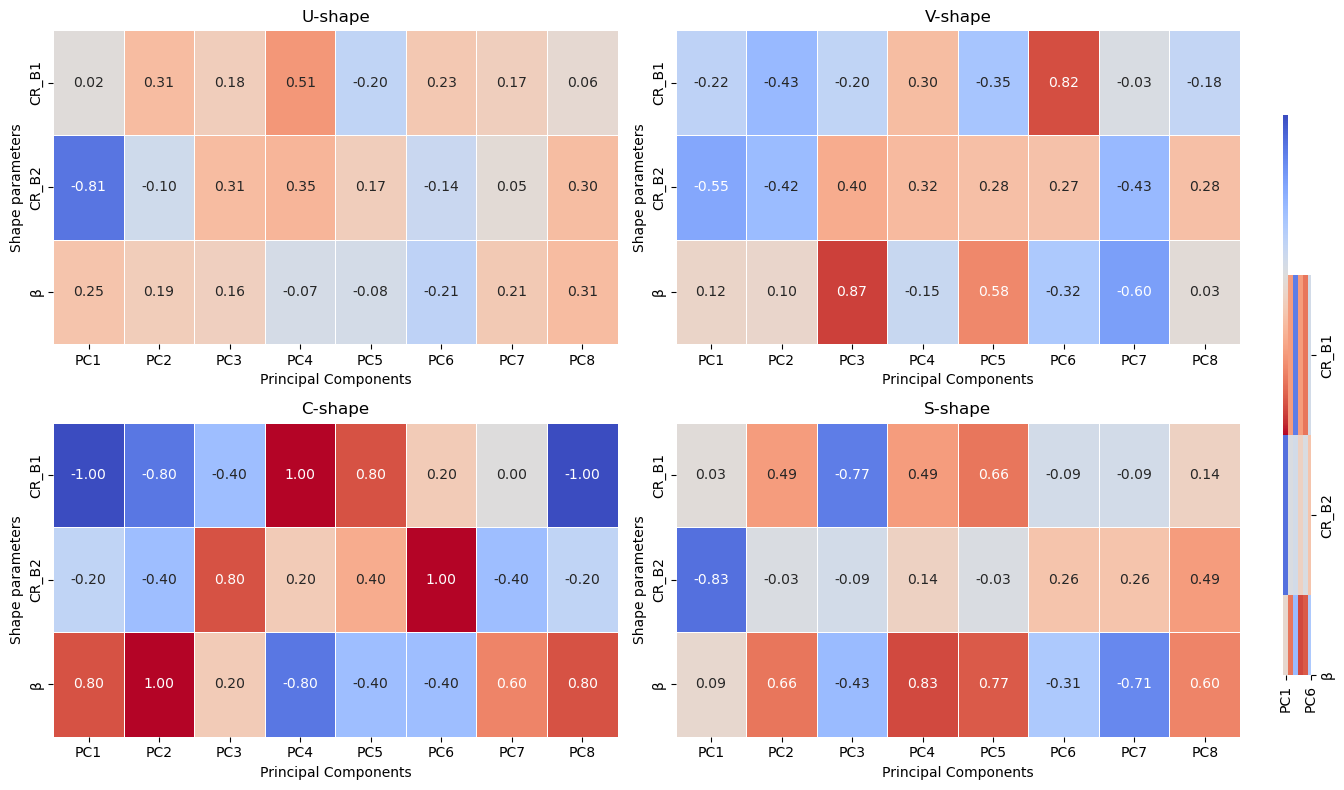

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. File paths
# =========================
json_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/5_PCA/"
    "siphon_aligned_with_PCs.json"
)

csv_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/3_Classification/"
    "classified_centerlines_BestDrop.csv"
)

# =========================
# 2. Load & merge data
# =========================
df_cls = pd.read_csv(csv_path)

with open(json_path, "r") as f:
    pcs_data = json.load(f)

rows = []
for fname, content in pcs_data.items():
    row = {"Filename": fname.replace(".vtk", "")}
    for k, v in content["pcs"].items():
        row[k] = v
    rows.append(row)

df_pcs = pd.DataFrame(rows)
df = pd.merge(df_cls, df_pcs, on="Filename", how="inner")

# =========================
# 3. Parameters
# =========================
shape_params = ["CR_B1", "CR_B2", "β"]
pcs = [f"PC{i}" for i in range(1, 9)]
types = ["U", "V", "C", "S"]

# =========================
# 4. UVCS-wise heatmaps
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

vmin, vmax = -1, 1  # 固定范围，便于比较

for ax, t in zip(axes, types):
    df_sub = df[df["Type"] == t]

    corr = pd.DataFrame(index=shape_params, columns=pcs, dtype=float)
    for sp in shape_params:
        for pc in pcs:
            corr.loc[sp, pc] = df_sub[sp].corr(
                df_sub[pc],
                method="spearman"
            )

    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        cbar=False
    )

    ax.set_title(f"{t}-shape")
    ax.set_xlabel("Principal Components")
    ax.set_ylabel("Shape parameters")

# ---- shared colorbar ----
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cbar_ax=cbar_ax,
    annot=False
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


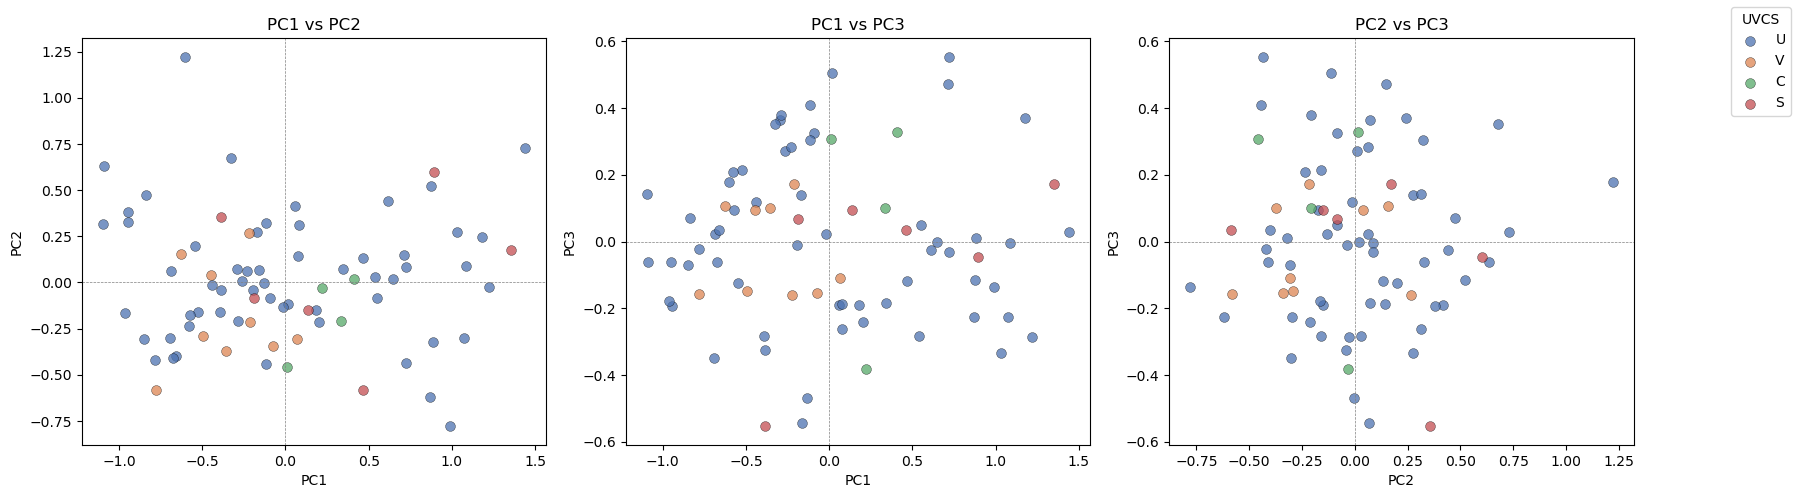

In [7]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# =========================
# 1. File paths
# =========================
json_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/5_PCA/"
    "siphon_aligned_with_PCs.json"
)

csv_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/3_Classification/"
    "classified_centerlines_BestDrop.csv"
)

# =========================
# 2. Load CSV (UVCS info)
# =========================
df_cls = pd.read_csv(csv_path)

# =========================
# 3. Load PCA JSON
# =========================
with open(json_path, "r") as f:
    pcs_data = json.load(f)

rows = []
for fname, content in pcs_data.items():
    row = {"Filename": fname.replace(".vtk", "")}
    for k, v in content["pcs"].items():
        row[k] = v
    rows.append(row)

df_pcs = pd.DataFrame(rows)

# =========================
# 4. Merge
# =========================
df = pd.merge(df_cls, df_pcs, on="Filename", how="inner")

# =========================
# 5. Plot settings
# =========================
color_map = {
    "U": "#4C72B0",
    "V": "#DD8452",
    "C": "#55A868",
    "S": "#C44E52"
}

pc_pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

# =========================
# 6. Scatter plots
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

for ax, (pc_x, pc_y) in zip(axes, pc_pairs):
    for t, color in color_map.items():
        df_sub = df[df["Type"] == t]

        ax.scatter(
            df_sub[pc_x],
            df_sub[pc_y],
            label=t,
            color=color,
            s=50,
            alpha=0.75,
            edgecolor="k",
            linewidth=0.3
        )

    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.set_title(f"{pc_x} vs {pc_y}")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

# Legend (shared)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="UVCS",
    loc="upper right"
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


In [2]:
import matplotlib
matplotlib.use("TkAgg")

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors

# =========================
# Paths
# =========================
json_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/5_PCA/"
    "siphon_aligned_with_PCs.json"
)

csv_path = (
    "/Users/harujane/Documents/6_github/Phd_summary/"
    "3_Result/1_Brava/1_Centerline/3_Classification/"
    "classified_centerlines_BestDrop.csv"
)

# =========================
# Color mapping (fixed)
# =========================
uvcs_color_map = {
    "U": "tab:blue",
    "V": "tab:orange",
    "C": "tab:green",
    "S": "tab:red",
}

# =========================
# Helpers
# =========================
def norm_key(x: str) -> str:
    """
    Normalize identifiers so CSV and JSON can match.
    - keep basename
    - remove extension
    """
    if x is None:
        return ""
    x = str(x).strip()
    x = os.path.basename(x)
    x = os.path.splitext(x)[0]
    return x

def pick_col(cols, keywords):
    """Pick the first column whose name contains any keyword (case-insensitive)."""
    cols_lower = {c: c.lower() for c in cols}
    for c, cl in cols_lower.items():
        if any(k in cl for k in keywords):
            return c
    return None

# =========================
# 1) Read classification CSV → build mapping
# =========================
df_cls = pd.read_csv(csv_path)

# 自动猜列名（你不用先改 CSV）
# - 文件名列可能叫：file, filename, vtk, centerline, path, name ...
# - 分类列可能叫：class, label, type, uvcs, group ...
file_col = pick_col(df_cls.columns, ["file", "filename", "vtk", "centerline", "path", "name"])
cls_col  = pick_col(df_cls.columns, ["uvcs", "class", "label", "type", "group"])

if file_col is None or cls_col is None:
    raise RuntimeError(
        "在 classified_centerlines_BestDrop.csv 里没能自动识别列名。\n"
        f"当前列名：{list(df_cls.columns)}\n\n"
        "请手动在代码里指定：file_col='你的文件名列'，cls_col='你的分类列'。"
    )

# 建立映射：normalized_file_key -> UVCS
cls_map = {}
for _, r in df_cls.iterrows():
    k = norm_key(r[file_col])
    v = str(r[cls_col]).strip().upper()
    cls_map[k] = v

print(f"[INFO] Classification map size: {len(cls_map)}")
print(f"[INFO] Using columns: file_col='{file_col}', cls_col='{cls_col}'")

# =========================
# 2) Read PCA JSON → extract PC1/PC2 + match UVCS
# =========================
with open(json_path, "r") as f:
    data = json.load(f)

cases, pc1, pc2, uvcs_labels, colors = [], [], [], [], []
missing = 0

for fname, content in data.items():
    pcs = content.get("pcs", None)  # 你的 JSON 用的是小写 pcs
    if pcs is None:
        continue
    if "PC1" not in pcs or "PC2" not in pcs:
        continue

    key = norm_key(fname)  # 用同样的归一化规则匹配
    uvcs = cls_map.get(key, "Unknown")

    cases.append(fname)
    pc1.append(pcs["PC1"])
    pc2.append(pcs["PC2"])
    uvcs_labels.append(uvcs)
    colors.append(uvcs_color_map.get(uvcs, "gray"))

    if uvcs == "Unknown":
        missing += 1

print(f"[INFO] Number of PCA points: {len(cases)}")
print(f"[INFO] Missing classification: {missing}")

if len(cases) == 0:
    raise RuntimeError("No PC points extracted from JSON. Check JSON structure and keys.")

# =========================
# 3) Plot (interactive)
# =========================
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pc1, pc2, c=colors, s=40, alpha=0.85)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("ICA Siphon PCA: PC1 vs PC2 (UVCS from CSV)")
ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(0, linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(True, linestyle=":", alpha=0.4)

# Legend (U/V/C/S only)
for uvcs, color in uvcs_color_map.items():
    ax.scatter([], [], c=color, label=uvcs, s=40)
ax.scatter([], [], c="gray", label="Unknown", s=40)
ax.legend(title="UVCS", frameon=True)

# Hover interaction
cursor = mplcursors.cursor(sc, hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(
        f"{os.path.basename(cases[i])}\n"
        f"Type: {uvcs_labels[i]}\n"
        f"PC1 = {pc1[i]:.3f}\n"
        f"PC2 = {pc2[i]:.3f}"
    )
    sel.annotation.get_bbox_patch().set(alpha=0.9)

plt.tight_layout()
plt.show()


[INFO] Classification map size: 77
[INFO] Using columns: file_col='Filename', cls_col='Type'
[INFO] Number of PCA points: 77
[INFO] Missing classification: 0
